In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [161]:
#создаем датафрейм
df0 = pd.read_csv('/Users/spyridonmibers/Desktop/How-Much-Is-The-real-estate-in-Moscow/datasets/_data.csv')

In [162]:
#оставляем мои колонки
df1 = df0[['ID  объявления', 'Количество комнат','Тип', 'Площадь, м2', 'Площадь комнат, м2', 'Ремонт', 'Балкон', 'Окна', 'Санузел', 'Высота потолков, м', 'Серия дома']].copy()

In [163]:
#оставляем только количество комнат и убираем лишние слова
import re

def clean_rooms(value):
    
    if pd.isna(value):
        return None
    #первое число в строке
    match = re.search(r'(\d+)', str(value))
    return int(match.group(1)) if match else None

df1['Количество комнат'] = df1['Количество комнат'].apply(clean_rooms)
df1['Количество комнат'] = pd.to_numeric(df1['Количество комнат'], errors='coerce').astype('Int64')


#площадь разобъем на три колонки "общую", "жилую" и "кухню"

In [164]:
def split_area(area_str):
    if pd.isna(area_str):
        return pd.Series([None, None, None])
    parts = str(area_str).split('/')
    total = float(parts[0]) if len(parts) > 0 else None
    living = float(parts[1]) if len(parts) > 1 else None
    kitchen = float(parts[2]) if len(parts) > 2 else None
    return pd.Series([total, living, kitchen])
#теперь сама функция
df1[['Площадь_общая', 'Площадь_жилая', 'Площадь_кухня']] = df1['Площадь, м2'].apply(split_area)


In [165]:
#теперь уберем изначальную колонку площадь и NaN из новых колонок
df = df1.drop('Площадь, м2', axis=1)
df.drop('Тип', axis=1, inplace=True)
df.drop('Высота потолков, м', axis=1, inplace=True)
df.drop('Площадь комнат, м2', axis=1, inplace=True)
df.drop('Серия дома', axis=1, inplace=True)
df.drop('Окна', axis=1, inplace=True)
df.drop('Санузел', axis=1, inplace=True)
df.drop('Площадь_кухня', axis=1, inplace=True)

df.drop('Площадь_жилая', axis=1, inplace=True)
pd.unique(df['Ремонт'])
pd.unique(df['Балкон'])

array([nan, 'Балкон (1)', 'Балкон (3)', 'Лоджия (1)',
       'Балкон (2), Лоджия (3)', 'Балкон (1), Лоджия (1)', 'Балкон (2)',
       'Лоджия (2)', 'Балкон (3), Лоджия (3)', 'Балкон (3), Лоджия (1)',
       'Лоджия (3)', 'Балкон (1), Лоджия (2)', 'Балкон (2), Лоджия (1)',
       'Балкон (2), Лоджия (2)', 'Балкон (1), Лоджия (3)', 'Балкон (4)',
       'Лоджия (4)', 'Балкон (4), Лоджия (4)', 'Балкон (1), Лоджия (4)'],
      dtype=object)

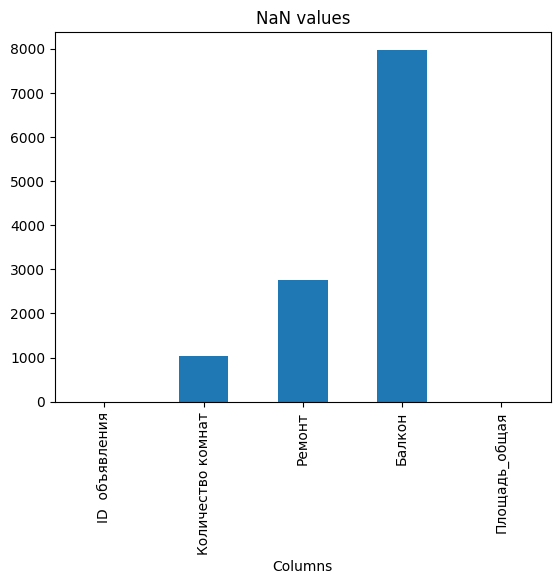

In [166]:
nan = df.isna().sum()
nan.plot(kind='bar')
plt.title('NaN values')
plt.xlabel('Columns')
plt.show()

Даем цифровые значения для NaN

In [167]:
#сначала разделим балкон на 2 колонки "Балкон" и "Лоджия" и там где NaN поставим значение 0
import pandas as pd
import re

def split_categorical_column(df, column_name, categories_dict):
    df_result = df.copy()
    
    for new_col, keyword in categories_dict.items():
        df_result[new_col] = df[column_name].apply(
            lambda x: 1 if pd.notna(x) and keyword.lower() in str(x).lower() else 0
        )
    
    def extract_count(value):
        if pd.isna(value):
            return 0
        match = re.search(r'\((\d+)\)', str(value))
        return int(match.group(1)) if match else 0
    
    df_result[f'{column_name}'] = df[column_name].apply(extract_count)
    
    return df_result

categories = {
    'Балкон': 'балкон',
    'Лоджия': 'лоджия',
}

df = split_categorical_column(df, 'Балкон', categories)

In [168]:
df['Количество комнат'] = df['Количество комнат'].fillna(0)
df

,ID объявления,Количество комнат,Ремонт,Балкон,Площадь_общая,Лоджия
0,271271157,4,Дизайнерский,0,200.0,0
1,271634126,4,Дизайнерский,0,198.0,0
2,271173086,4,Евроремонт,0,200.0,0
3,272197456,4,Евроремонт,0,170.0,0
4,273614615,2,Евроремонт,0,58.0,0
...,...,...,...,...,...,...
23363,215565511,0,Евроремонт,1,35.0,0
23364,274654844,1,Евроремонт,1,38.7,1
23365,268679909,2,Дизайнерский,1,43.1,0
23366,274807525,2,Евроремонт,1,52.5,1


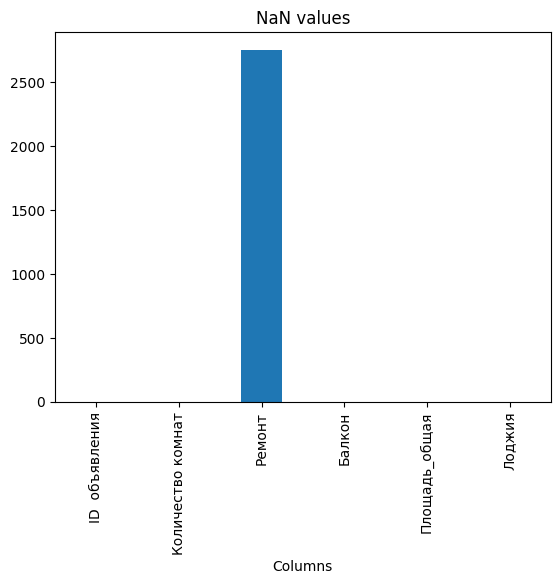

In [ ]:
nan = df.isna().sum()
nan.plot(kind='bar')
plt.title('NaN values')
plt.xlabel('Columns')
plt.show()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      Ффф